Import Libraries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Load Dataset

In [5]:
df = pd.read_csv(r"C:\Users\harsh\Downloads\framingham (2).csv")

print(df.head())

print(df.shape)

   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0           0  
1           0  
2 

Dataset Information

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB
None


Statistical Summary

In [7]:
print(df.describe())

              male          age    education  currentSmoker   cigsPerDay  \
count  4238.000000  4238.000000  4133.000000    4238.000000  4209.000000   
mean      0.429212    49.584946     1.978950       0.494101     9.003089   
std       0.495022     8.572160     1.019791       0.500024    11.920094   
min       0.000000    32.000000     1.000000       0.000000     0.000000   
25%       0.000000    42.000000     1.000000       0.000000     0.000000   
50%       0.000000    49.000000     2.000000       0.000000     0.000000   
75%       1.000000    56.000000     3.000000       1.000000    20.000000   
max       1.000000    70.000000     4.000000       1.000000    70.000000   

            BPMeds  prevalentStroke  prevalentHyp     diabetes      totChol  \
count  4185.000000      4238.000000   4238.000000  4238.000000  4188.000000   
mean      0.029630         0.005899      0.310524     0.025720   236.721585   
std       0.169584         0.076587      0.462763     0.158316    44.590334   

Column Names

In [8]:
print(df.columns)

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')


Missing Values

In [9]:
print(df.isnull().sum())

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


Duplicate Values

In [10]:
print(df.duplicated().sum())

0


Handling Missing Values

In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)

Remove Duplicates

In [13]:
df.drop_duplicates(inplace=True)

print(df.shape)

(4238, 16)


Histogram

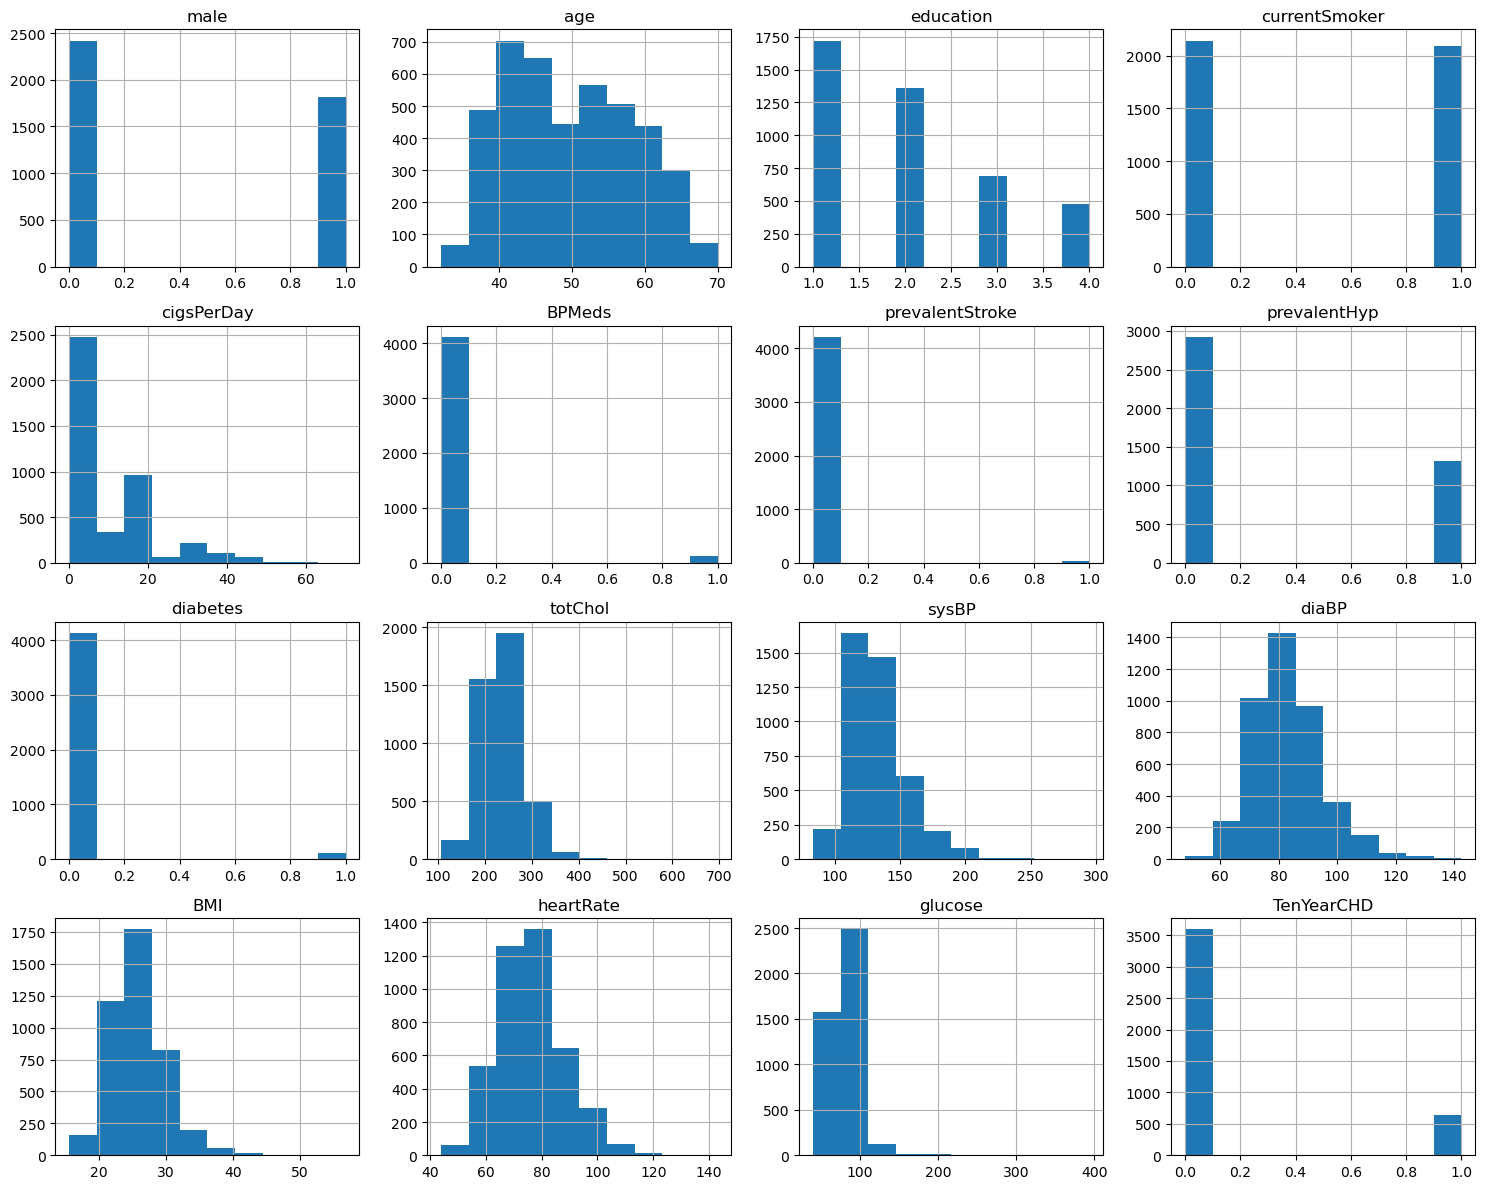

In [30]:
df.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

Bar Chart

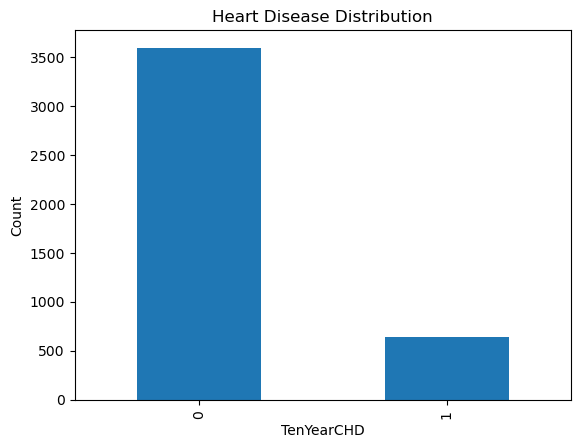

In [16]:
df["TenYearCHD"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")

plt.xlabel("TenYearCHD")

plt.ylabel("Count")

plt.show()

Pie chart

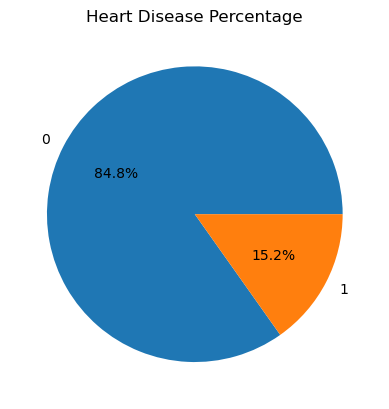

In [17]:
df["TenYearCHD"].value_counts().plot(
kind="pie",
autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Heart Disease Percentage")

plt.show()

Heatmap

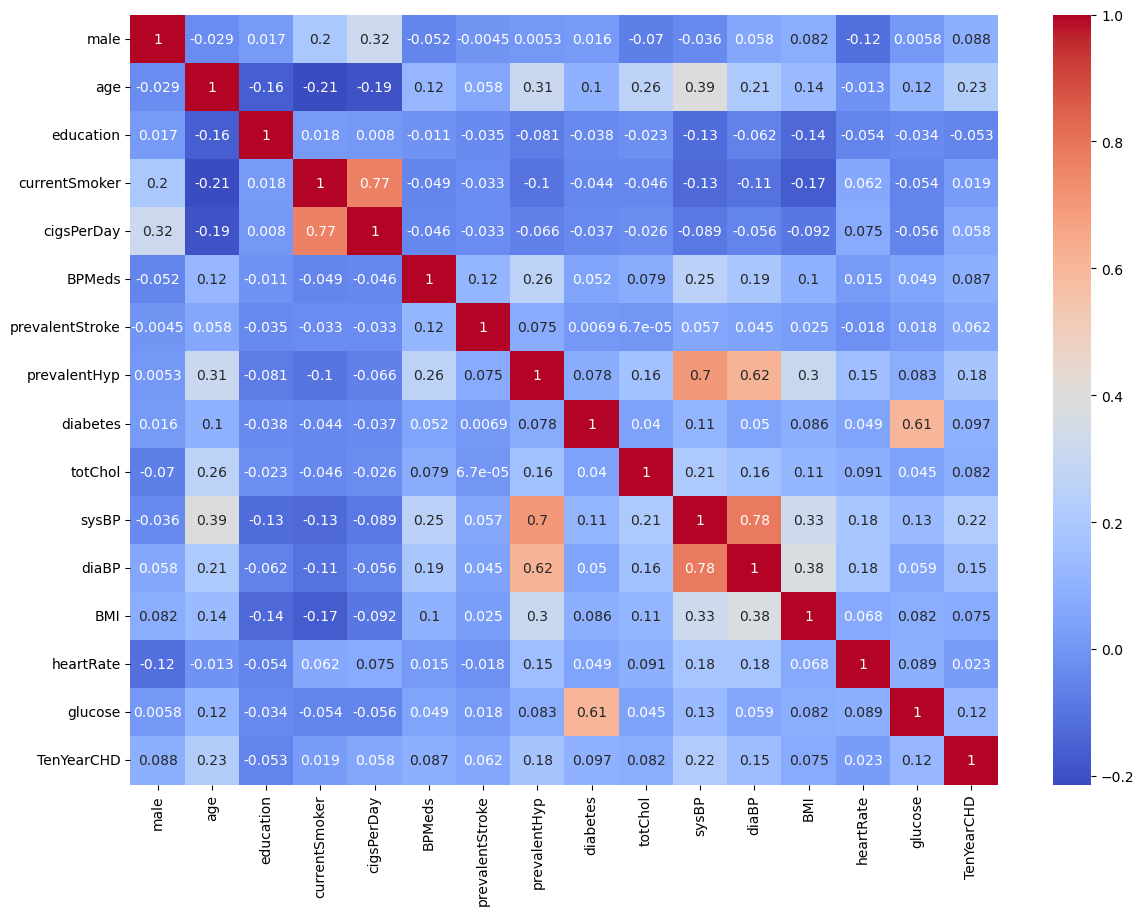

In [18]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

plt.show()

Feature Selection

In [19]:
X=df.drop("TenYearCHD",axis=1)

y=df["TenYearCHD"]

Train Test Split

In [20]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

Feature Scaling

In [21]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

Logistic Regression

In [22]:
lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

print("Logistic Regression Accuracy")

print(accuracy_score(y_test,pred_lr))

print(confusion_matrix(y_test,pred_lr))

print(classification_report(y_test,pred_lr))

Logistic Regression Accuracy
0.8573113207547169
[[718   6]
 [115   9]]
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       724
           1       0.60      0.07      0.13       124

    accuracy                           0.86       848
   macro avg       0.73      0.53      0.53       848
weighted avg       0.82      0.86      0.81       848



Decision Making

In [23]:
dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

pred_dt=dt.predict(X_test)

print("Decision Tree Accuracy")

print(accuracy_score(y_test,pred_dt))

print(confusion_matrix(y_test,pred_dt))

print(classification_report(y_test,pred_dt))

Decision Tree Accuracy
0.7606132075471698
[[612 112]
 [ 91  33]]
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       724
           1       0.23      0.27      0.25       124

    accuracy                           0.76       848
   macro avg       0.55      0.56      0.55       848
weighted avg       0.78      0.76      0.77       848



Random Forest

In [24]:
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

print("Random Forest Accuracy")

print(accuracy_score(y_test,pred_rf))

print(confusion_matrix(y_test,pred_rf))

print(classification_report(y_test,pred_rf))

Random Forest Accuracy
0.8514150943396226
[[711  13]
 [113  11]]
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       724
           1       0.46      0.09      0.15       124

    accuracy                           0.85       848
   macro avg       0.66      0.54      0.53       848
weighted avg       0.80      0.85      0.81       848



K-Nearest Neighbors

In [25]:
knn=KNeighborsClassifier()

knn.fit(X_train,y_train)

pred_knn=knn.predict(X_test)

print("KNN Accuracy")

print(accuracy_score(y_test,pred_knn))

print(confusion_matrix(y_test,pred_knn))

print(classification_report(y_test,pred_knn))

KNN Accuracy
0.8349056603773585
[[692  32]
 [108  16]]
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       724
           1       0.33      0.13      0.19       124

    accuracy                           0.83       848
   macro avg       0.60      0.54      0.55       848
weighted avg       0.79      0.83      0.80       848



Support Vector Machine(SVC)

In [26]:
svc=SVC()

svc.fit(X_train,y_train)

pred_svc=svc.predict(X_test)

print("SVC Accuracy")

print(accuracy_score(y_test,pred_svc))

print(confusion_matrix(y_test,pred_svc))

print(classification_report(y_test,pred_svc))

SVC Accuracy
0.8549528301886793
[[722   2]
 [121   3]]
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       724
           1       0.60      0.02      0.05       124

    accuracy                           0.85       848
   macro avg       0.73      0.51      0.48       848
weighted avg       0.82      0.85      0.79       848



Compare All Models

In [27]:
results=pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVC"
    ],
    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_knn),
        accuracy_score(y_test,pred_svc)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.857311
1        Decision Tree  0.760613
2        Random Forest  0.851415
3                  KNN  0.834906
4                  SVC  0.854953


Best Model

In [28]:
best=results.loc[results["Accuracy"].idxmax()]

print("Best Model")

print(best)

Best Model
Model       Logistic Regression
Accuracy               0.857311
Name: 0, dtype: object
